## This notebook serves as a template for comparing different masking functions for lambda_PDE and lambda_TV. A choice of TV penalization for u_x or u_xx can be chosen as well.

In [2]:
import numpy as np
import sys

sys.path.append('..')  # add project root

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

import importlib
importlib.reload(mlps)
importlib.reload(trainer)
importlib.reload(hlprs)
importlib.reload(lmf)

<module 'Datasets.load_mat_as_flat' from 'c:\\Users\\Ethan\\Desktop\\Research\\pde_stuff\\ethan_work\\..\\Datasets\\load_mat_as_flat.py'>

In [7]:
# learning these
lam_tv = 1e-9
lam_pde = 1.0

lr_tv = 1e-4
lr_pde = 1e-3

#not learning these
lam_reg = 0.0
lam_data = 10.0

# hyperparameters for data generation
path = "../Datasets/data/raw/burgers.mat"
data = sio.loadmat(path)
noise=0.5
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

selected_derivs = ('u','u_x','u_xx')

correct_coeffs = [0.0, 0.0, nu, -1.0]  # corresponds to the correct PDE: u_t + u*u_x - nu*u_xx = 0


lr = 1e-3
batch_size = 1000
epoch = data["t"].shape[0] * data["x"].shape[1]
steps_per_epoch = epoch // batch_size
steps = 60 #6000
log_every = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# building noisy dataset
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

print(type(t_np), t_np.shape)
# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print("other points:", type(x_np.shape[0]))
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))

Using device: cuda
<class 'numpy.ndarray'> (25856,)
N points: 25856
other points: <class 'int'>
x_unique: 256 t_unique: 101


c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


We'd like to be able to loop through different model iterations, with each iteration using a different masking function

In [4]:
def tv_mask_1(lam):
    return 1e-8 + 1e-4 * (1 / (1 + torch.exp(-(lam-1))))
def pde_mask_1(lam):
    return 40 * (1 / (1 + torch.exp(-(lam-1))))

def tv_mask_2(lam):
    return 1e-8 + 1e-4 * (1 / (1 + torch.exp(-(lam-1))))
def pde_mask_2(lam):
    return lam

def tv_mask_3(lam):
    return lam
def pde_mask_3(lam):
    return 40 * (1 / (1 + torch.exp(-(lam-1))))

def tv_mask_4(lam):
    return lam
def pde_mask_4(lam):
    return lam

tv_masks = [tv_mask_1, tv_mask_2, tv_mask_3, tv_mask_4]
pde_masks = [pde_mask_1, pde_mask_2, pde_mask_3, pde_mask_4]

In [5]:
def tv1d_space_ux_penalize(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()

def tv1d_space_uxx_penalize(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    uxx = torch.autograd.grad(
        ux, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(uxx**2 + eps**2)
    return tv.mean()

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet, tv_mask_fn, pde_mask_fn):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        lambda_tv_mask_fn = tv_mask_fn,
        lambda_pde_mask_fn = pde_mask_fn,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.SAPINNScalarTrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

## Looping through different masking function combinations and training each corresponding model


 
 
 
* * * * * * * * * * * * * 
running models with test1 masking functions...
Starting training loop...
Initial lambda_tv: 9.999999717180685e-10, Initial lambda_pde: 1.0000
step 0:


c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


step 500:
loss 0.1179
step 1000:
loss 0.0932
step 1500:
loss 0.0886
step 2000:
loss 0.0845
step 2500:
loss 0.0914
step 3000:
loss 0.0893
step 3500:
loss 0.0845
step 4000:
loss 0.0922
step 4500:
loss 0.0817
step 5000:
loss 0.0819
step 5500:
loss 0.0835
step 6000:
loss 0.0914
Starting second training loop with fixed lambda values...
step 500:
loss 0.0893
step 1000:
loss 0.0843
step 1500:
loss 0.0843
step 2000:
loss 0.0932
step 2500:
loss 0.0866
step 3000:
loss 0.0904
step 3500:
loss 0.0910
step 4000:
loss 0.0861
step 4500:
loss 0.0901
step 5000:
loss 0.0846
step 5500:
loss 0.0814
step 6000:
loss 0.0799
max_abs_diff = 0.0450163

 
 
 
* * * * * * * * * * * * * 
running models with test2 masking functions...
Starting training loop...
Initial lambda_tv: 9.999999717180685e-10, Initial lambda_pde: 1.0000
step 0:
step 500:
loss 0.0936
step 1000:
loss 0.0864
step 1500:
loss 0.0910
step 2000:
loss 0.0803
step 2500:
loss 0.0854
step 3000:
loss 0.0841
step 3500:
loss 0.0849
step 4000:
loss 0.0902


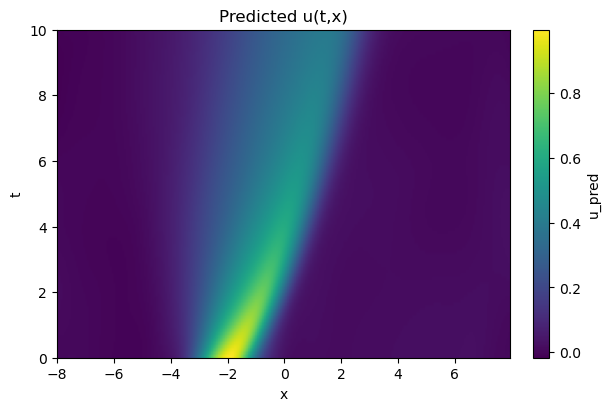

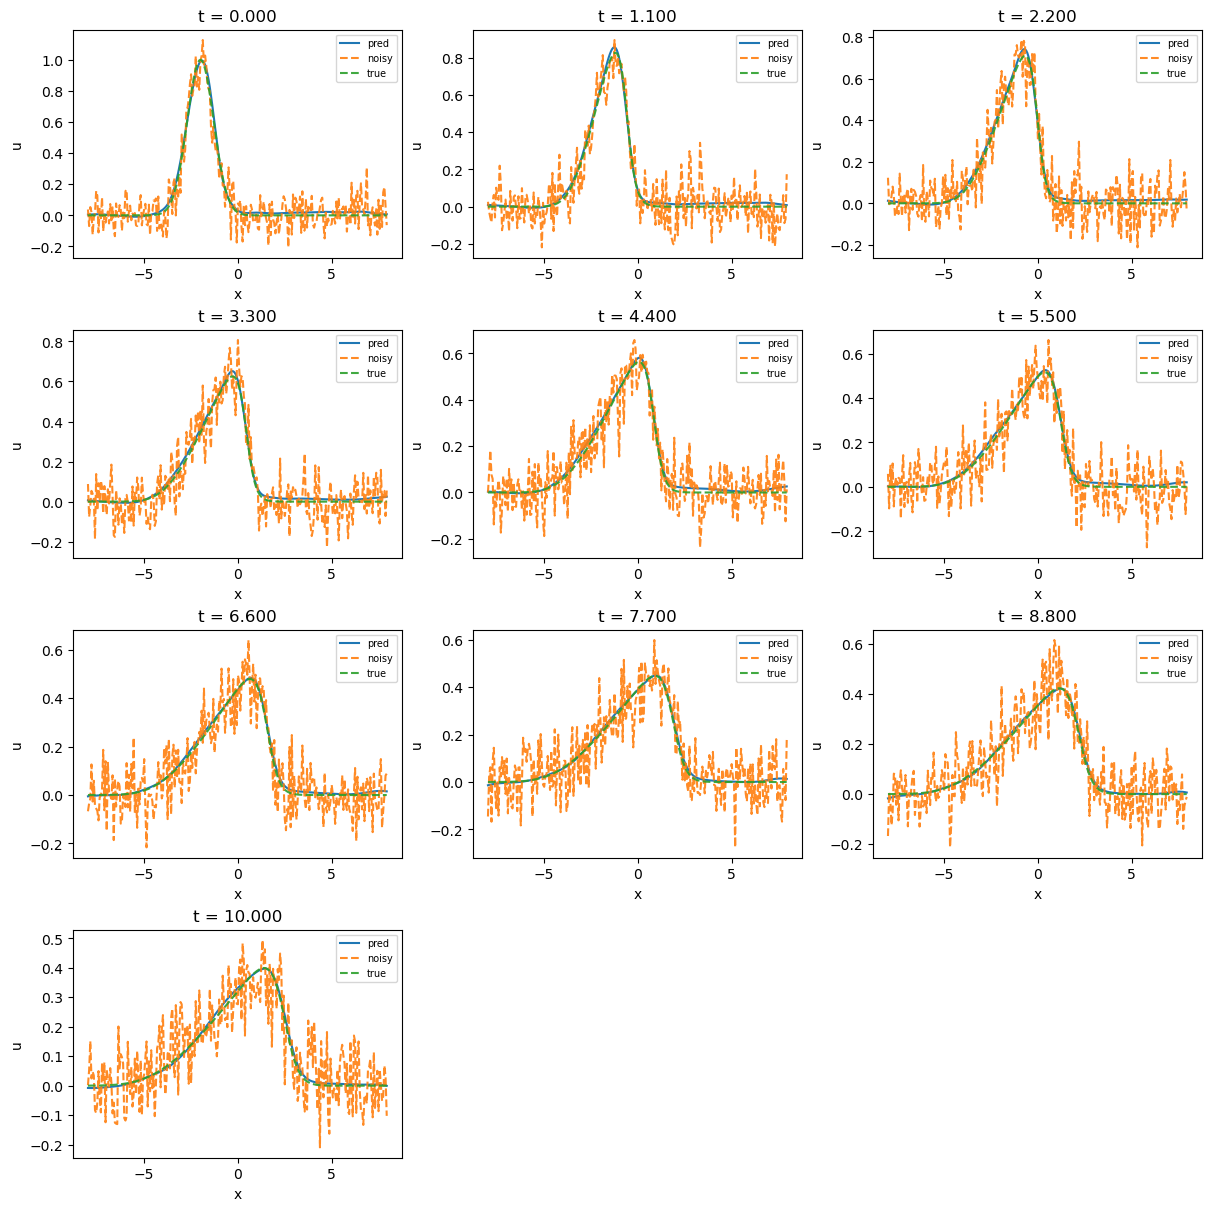

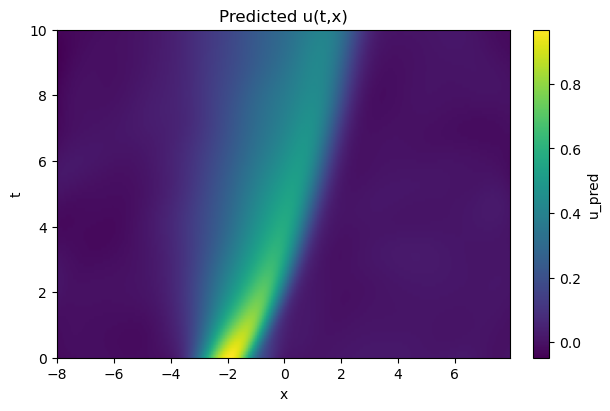

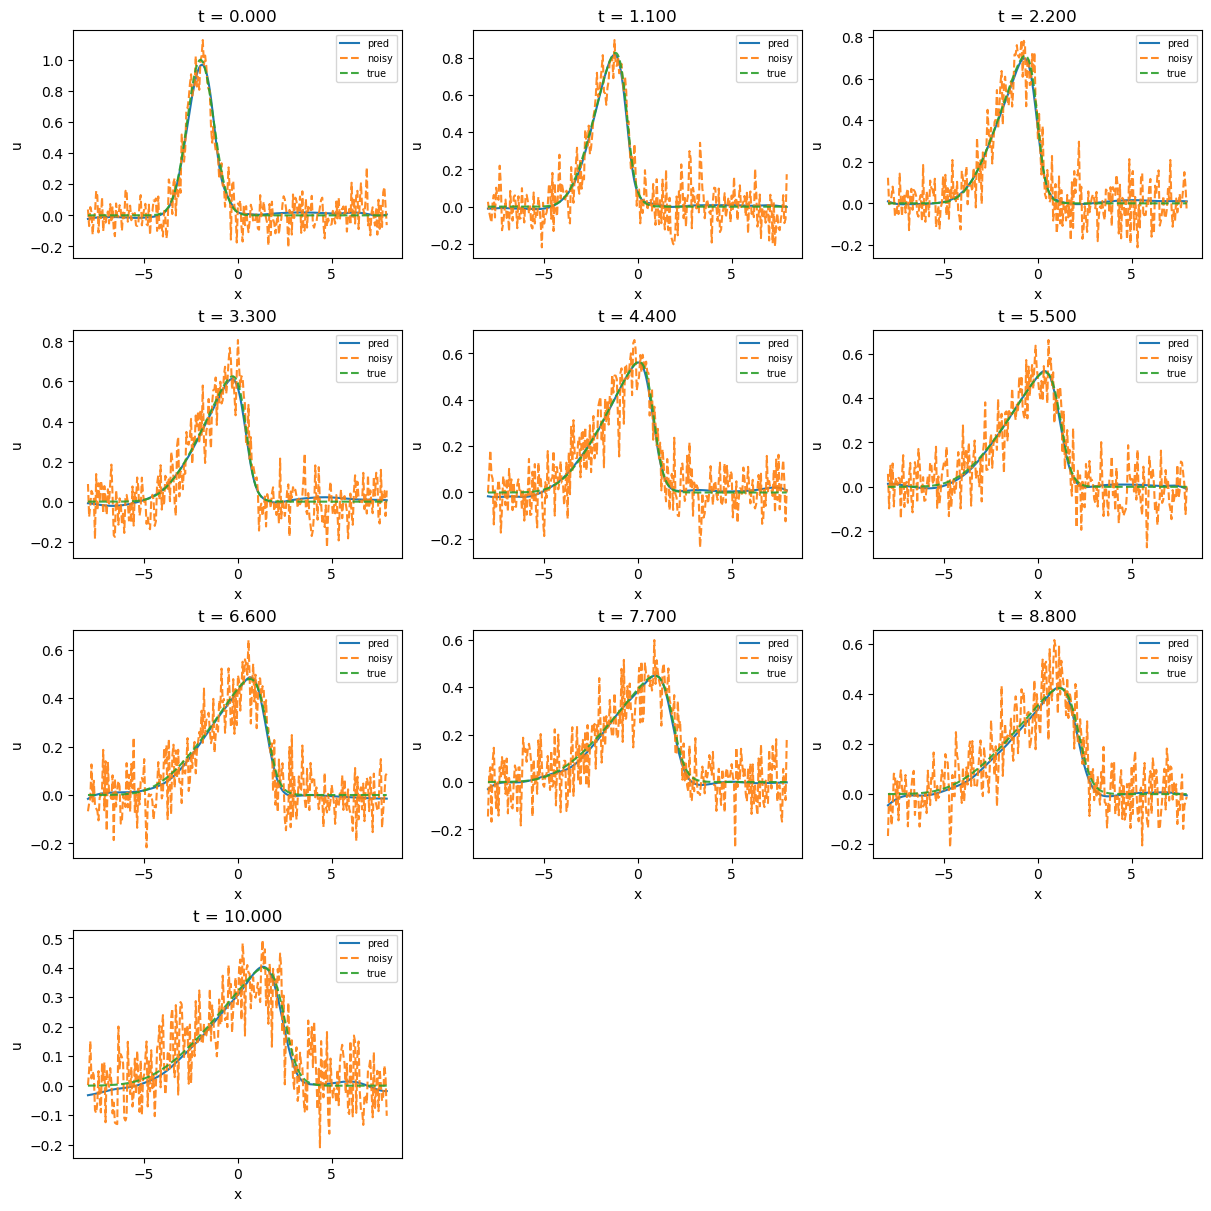

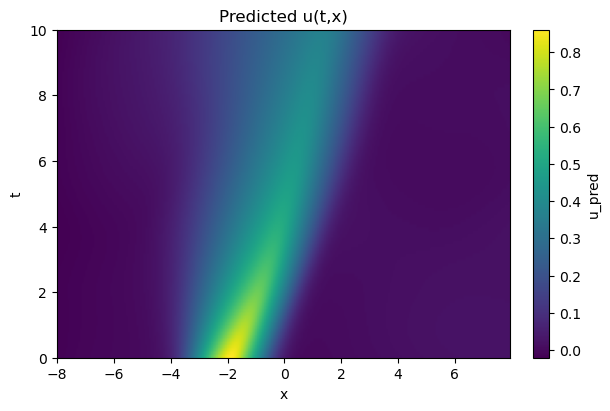

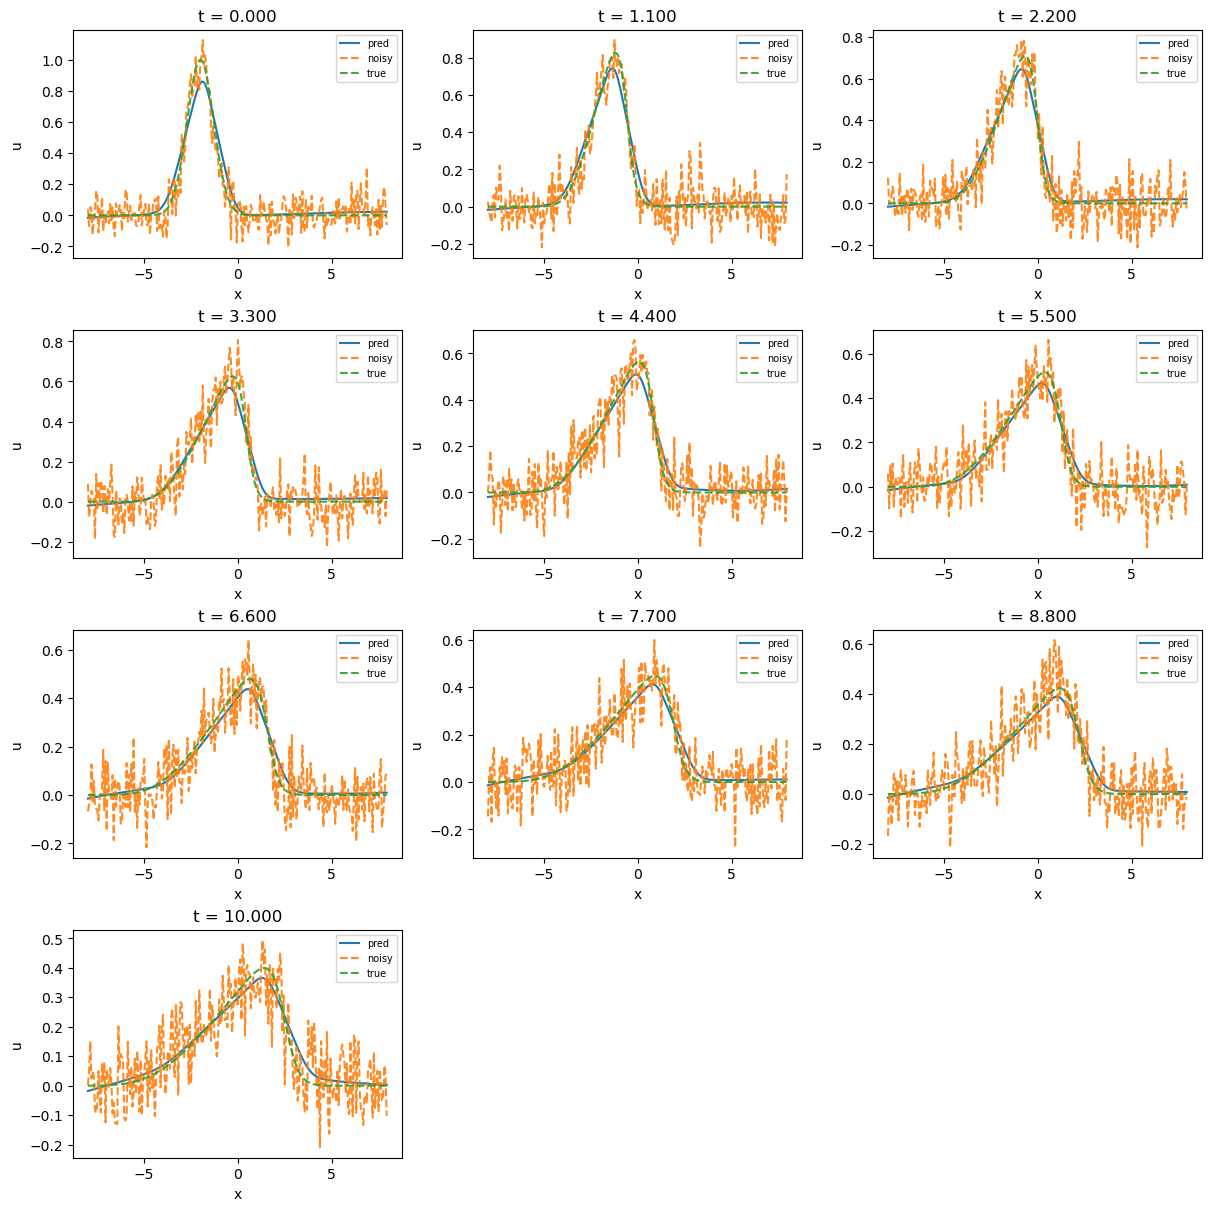

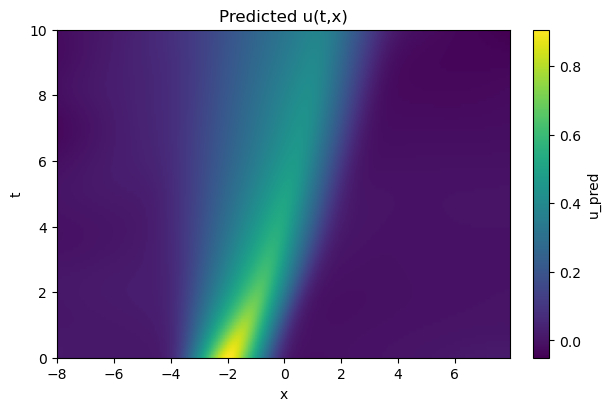

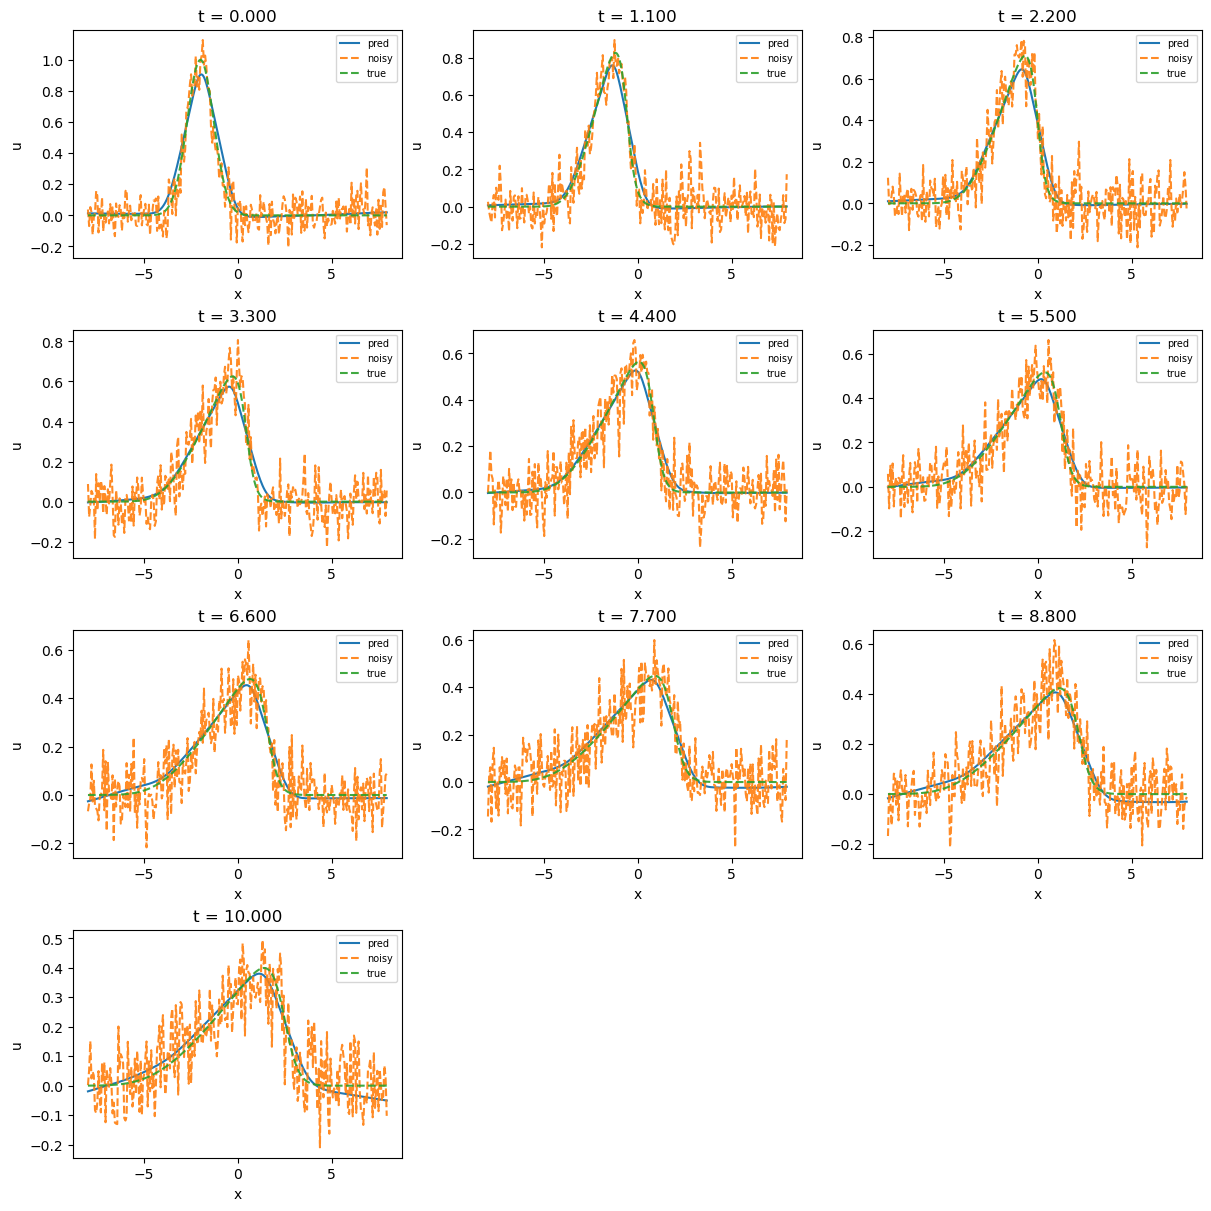

In [6]:
json_names = ["test1", "test2", "test3", "test4"]


for pde_mask_fn, tv_mask_fn, json_name in zip(pde_masks, tv_masks, json_names):
    print("\n \n \n \n* * * * * * * * * * * * * ")
    print(f"running models with {json_name} masking functions...")
    u_model, symnet = make_models()
    train = make_trainer(u_model, symnet, tv_mask_fn, pde_mask_fn)


    print('Starting training loop...')
    print(f'Initial lambda_tv: {train.lambda_tv.item()}, Initial lambda_pde: {train.lambda_pde.item():.4f}')
    print(f'step {0}:')

    lambda_tv_values = []
    lambda_pde_values = []
    lambda_values = [lambda_tv_values, lambda_pde_values]
    lambda_names = ["lambda_tv", "lambda_pde"]

    masked_lambda_pde_values = []
    masked_lambda_tv_values = []

    total_losses = []
    data_losses = []
    pde_losses = []
    tv_losses = []
    coeff_losses = []
    losses = [total_losses, data_losses, pde_losses, tv_losses]#, coeff_losses]
    loss_names = ["total_loss", "data_loss", "pde_loss", "tv_loss"]#, "coeff_loss"]

    train.lambda_pde.requires_grad_(True)
    train.lambda_tv.requires_grad_(True)
    # first, train to find best lambda values (using ADAM)
    for i in range(6000): 
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_clean_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space_uxx_penalize)
        # append values for plotting later
        lambda_tv_values.append(out["lambda_tv"])
        lambda_pde_values.append(out["lambda_pde"])
        masked_lambda_pde_values.append(out["mask_pde"])
        masked_lambda_tv_values.append(out["mask_tv"])
        total_losses.append(out["loss"])
        data_losses.append(out["loss_data"])
        pde_losses.append(out["loss_pde_weighted"])
        tv_losses.append(out["loss_tv_weighted"])
        # coeff_losses.append(out["loss_coeff"])

        if (i + 1)%log_every==0:
            print(f'step {i +1}:')
            print(f'loss {out["loss"]:.4f}')
            # print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
            # print(f'loss_tv_masked" {out["mask_tv"]:}  | loss_pde_masked {out["mask_pde"]:.4f}')
            # print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
            # model_loss = out["loss"]


    
    # now fix lambda values and train just the loss parameters (still using ADAM, since LBFGS is hard to implement)
    train.cfg.lr_tv = 0.0
    train.cfg.lr_pde = 0.0

    train.lambda_pde.requires_grad_(False)
    train.lambda_tv.requires_grad_(False)
    print('Starting second training loop with fixed lambda values...')
    out = None
    for i in range(6000):
        # apparently, lbfgs does better with full-batch training.
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_clean_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space_uxx_penalize)
        # append values for plotting later
        lambda_tv_values.append(out["lambda_tv"])
        lambda_pde_values.append(out["lambda_pde"])
        masked_lambda_pde_values.append(out["mask_pde"])
        masked_lambda_tv_values.append(out["mask_tv"])
        total_losses.append(out["loss"])
        data_losses.append(out["loss_data"])
        pde_losses.append(out["loss_pde_weighted"])
        tv_losses.append(out["loss_tv_weighted"])

        if (i + 1)%500==0:
            print(f'step {i +1}:')
            print(f'loss {out["loss"]:.4f}')
            # print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
            # print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
            # print(f'lambda_tv_masked {out["mask_tv"]} | lambda_pde_masked {out["mask_pde"]:.4f}')

    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]
    run_dir = f"../ethan_work/mask_fns_runs/uxx_tv_penalization/{json_name}/"
    hlprs.general_plot(list_of_lists = losses, name_list = loss_names, ylabel = "Loss", title = "Training Losses", filename = "training_losses.png", run_dir = run_dir)
    hlprs.general_plot(list_of_lists = lambda_values, name_list = lambda_names, ylabel = "Lambda", title = "Training Lambda Values (UNMASKED)", filename = "training_UNMASKED_values.png", run_dir = run_dir)
    hlprs.general_plot(list_of_lists = [masked_lambda_tv_values, masked_lambda_pde_values], name_list = lambda_names, ylabel = "Lambda", title = "Training Lambda Values (MASKED)", filename = "training_MASKED_values.png", run_dir = run_dir)

    hlprs.save_to_json(train, out, correct_coeffs, path=f"../ethan_work/mask_fns_runs/uxx_tv_penalization/{json_name}/{json_name}.json")
        

## Taking JSON meta data from tests 1 through 4 and group them all into one CSV file for displaying

In [38]:
# !pip install pandas
file_names = ["test1", "test2", "test3", "test4"]

paths = [f"../ethan_work/mask_fns_runs/uxx_tv_penalization/{json_name}/{json_name}.json" for json_name in file_names]

import json
import csv

data = [json.load(open(path, "r")) for path in paths]

print(data[3].keys())

# row 1
rows = []
header = [['hyperparameters', 'test1', 'test2', 'test3', 'test4']]
rows.append(header[0])
# print(rows)
# with open('output.csv', mode='w', newline='') as file:
#         writer = csv.writer(file)
#         writer.writerow(header)
print([data[i]['loss'] for i in range(len(header[0])-1)])
for row in data[0].keys():
    test_values = [[data[i][row] for i in range(len(header[0]) - 1)]]
    total_row = [[row] + test_values[0]]
    rows.append(total_row[0])
    
with open('uxx_penalize_results.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(rows)
print(rows)

dict_keys(['loss', 'loss_data', 'loss_pde_raw', 'lambda_pde', 'mask_pde', 'loss_pde_weighted', 'l1', 'loss_tv_raw', 'lambda_tv', 'mask_tv', 'loss_tv_weighted', 'feature_names', 'feature_scales', 'mask_pde_source', 'mask_tv_source', 'learned_coeffs', 'correct_coeffs', 'coeff_error'])
[0.07993093878030777, 0.08592897653579712, 0.12885558605194092, 0.11805130541324615]
[['hyperparameters', 'test1', 'test2', 'test3', 'test4'], ['loss', 0.07993093878030777, 0.08592897653579712, 0.12885558605194092, 0.11805130541324615], ['loss_data', 0.007955064065754414, 0.008575093001127243, 0.009624349884688854, 0.008605736307799816], ['loss_pde_raw', 1.5648409316781908e-05, 9.98411705950275e-05, 3.3145475754281506e-05, 8.341788634425029e-05], ['lambda_pde', 1.4061343669891357, 1.7393743991851807, 1.273473858833313, 1.8065276145935059], ['mask_pde', 24.006423950195312, 1.7393743991851807, 22.71782112121582, 1.8065276145935059], ['loss_pde_weighted', 0.00037566234823316336, 0.00017366117390338331, 0.00075

## Below is a method for graphing the masking functions

In [ ]:
from typing import Callable, Optional
def graph_from_function(func: Optional[Callable], title: str, path: Optional[str] = None):
    # create input values
    lam = torch.linspace(0.0, 3.0, 200)

    # evaluate the function
    y = func(lam)

    # convert to NumPy for matplotlib
    lam_np = lam.cpu().numpy()
    y_np = y.detach().cpu().numpy()

    # plot
    plt.plot(lam_np, y_np)
    plt.yscale('log')
    plt.xlabel("lambda")
    plt.ylabel("tv_mask_1(lambda)")
    plt.title("tv_mask_1 curve")
    plt.grid(True)
    plt.show()
    if path is not None:
        plt.savefig(path, format='png')

# graph_from_function(tv_mask_1, title="tv_mask_1 curve")

NameError: name 'tv_mask_1' is not defined